In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Cargar datos
base = Path(r'C:\Users\hola\Desktop\proyecto\introduccion-progrmacion-cientifica-')
path = base / 'data' / 'game_info_cleaned.csv'
df = pd.read_csv(path)

print(f'Total de registros: {len(df)}')
print(f'Total de columnas: {len(df.columns)}')
print('\nPrimeras filas:')
display(df[['name', 'genres', 'metacritic']].head(10))

Total de registros: 474417
Total de columnas: 27

Primeras filas:


,name,genres,metacritic
0,D/Generation HD,Adventure||Puzzle,NaN
1,G Prime Into The Rain,Simulation||Indie,NaN
2,Land Sliders,Adventure||Arcade,NaN
3,Pixel Gear,Action||Indie,NaN
4,Gods and Idols,RPG||Strategy||Massively Multiplayer,NaN
5,Plague venue,NaN,NaN
6,The Moon Sliver (itch),Adventure,NaN
7,Red Entity,Action||Shooter,NaN
8,HippiesVsCops,Strategy,NaN
9,They Came Through the Floor,Platformer,NaN


In [2]:
# Procesar géneros y filtrar juegos con puntaje Metacritic
df_genres = df[df['metacritic'].notna() & df['genres'].notna()].copy()

print(f'Juegos con género y puntaje Metacritic: {len(df_genres)}')

# Expandir géneros (separados por ||)
genres_exploded = []
for idx, row in df_genres.iterrows():
    genres_list = str(row['genres']).split('||')
    for genre in genres_list:
        genre = genre.strip()
        if genre:
            genres_exploded.append({
                'genre': genre,
                'metacritic': row['metacritic'],
                'name': row['name']
            })

df_genres_expanded = pd.DataFrame(genres_exploded)
print(f'\nTotal de registros (género-juego): {len(df_genres_expanded)}')
print(f'Géneros únicos: {df_genres_expanded["genre"].nunique()}')
print('\nGéneros encontrados:')
print(df_genres_expanded['genre'].value_counts())

Juegos con género y puntaje Metacritic: 4686

Total de registros (género-juego): 11098
Géneros únicos: 19

Géneros encontrados:
genre
Action                   2544
Adventure                1681
Indie                    1561
RPG                      1023
Strategy                  941
Simulation                601
Shooter                   573
Casual                    406
Puzzle                    311
Arcade                    288
Racing                    262
Platformer                260
Sports                    258
Fighting                  119
Massively Multiplayer     110
Family                     84
Board Games                31
Card                       29
Educational                16
Name: count, dtype: int64


In [3]:
# Calcular puntaje promedio de Metacritic por género
genre_stats = df_genres_expanded.groupby('genre').agg({
    'metacritic': ['mean', 'median', 'std', 'count']
}).round(2)

genre_stats.columns = ['Promedio', 'Mediana', 'Desv.Est', 'Cantidad']
genre_stats = genre_stats.sort_values('Promedio', ascending=False)

print('Estadísticas de Metacritic por Género:')
display(genre_stats)

# Extraer datos para la gráfica
genres_names = genre_stats.index.tolist()
genres_means = genre_stats['Promedio'].tolist()
genres_counts = genre_stats['Cantidad'].astype(int).tolist()

print(f'\nGénero con mayor puntaje promedio: {genres_names[0]} ({genres_means[0]:.2f})')
print(f'Género con menor puntaje promedio: {genres_names[-1]} ({genres_means[-1]:.2f})')
print(f'Brecha entre máximo y mínimo: {genres_means[0] - genres_means[-1]:.2f} puntos')

Estadísticas de Metacritic por Género:


,Promedio,Mediana,Desv.Est,Cantidad
genre,,,,
Platformer,77.45,79.0,10.13,260
Massively Multiplayer,76.51,77.5,9.00,110
Educational,76.50,77.5,8.69,16
Card,76.00,76.0,9.32,29
Puzzle,75.98,76.0,8.32,311
Fighting,74.87,76.0,12.15,119
RPG,74.74,76.0,10.63,1023
Sports,74.68,76.5,10.95,258
Board Games,74.06,75.0,9.50,31



Género con mayor puntaje promedio: Platformer (77.45)
Género con menor puntaje promedio: Indie (71.67)
Brecha entre máximo y mínimo: 5.78 puntos


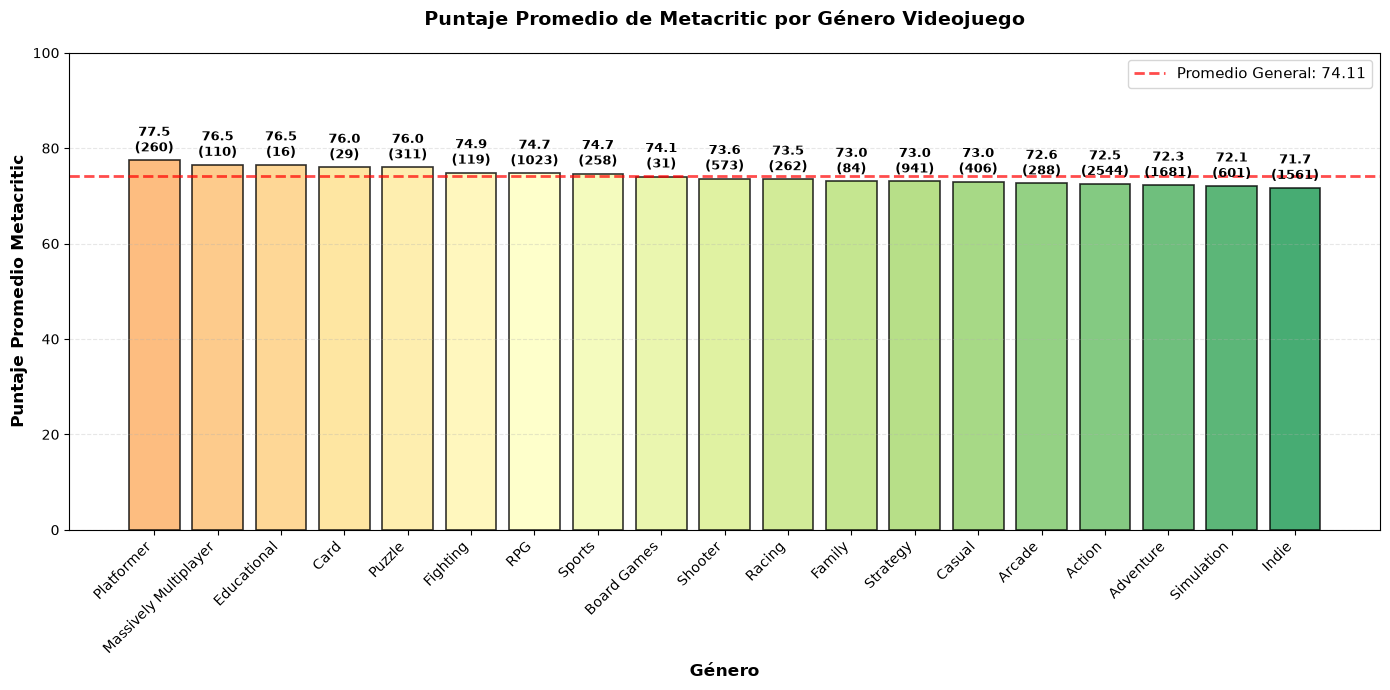

Gráfica generada exitosamente.


In [4]:
# Crear gráfica de barras verticales
fig, ax = plt.subplots(figsize=(14, 7))

# Colores degradados según el valor del puntaje
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(genres_means)))

# Ordenar por puntaje descendente para la visualización
sorted_indices = np.argsort(genres_means)[::-1]
sorted_genres = [genres_names[i] for i in sorted_indices]
sorted_means = [genres_means[i] for i in sorted_indices]
sorted_counts = [genres_counts[i] for i in sorted_indices]
sorted_colors = [colors[i] for i in sorted_indices]

barras = ax.bar(range(len(sorted_genres)), sorted_means, color=sorted_colors, 
                edgecolor='black', linewidth=1.2, alpha=0.8)

# Configuración del gráfico
ax.set_xlabel('Género', fontsize=12, fontweight='bold')
ax.set_ylabel('Puntaje Promedio Metacritic', fontsize=12, fontweight='bold')
ax.set_title('Puntaje Promedio de Metacritic por Género Videojuego', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(sorted_genres)))
ax.set_xticklabels(sorted_genres, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores en las barras
for i, (barra, valor, cantidad) in enumerate(zip(barras, sorted_means, sorted_counts)):
    height = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., height + 1,
            f'{valor:.1f}\n({cantidad})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea de referencia del promedio general
promedio_general = np.mean(genres_means)
ax.axhline(y=promedio_general, color='red', linestyle='--', linewidth=2, 
           label=f'Promedio General: {promedio_general:.2f}', alpha=0.7)

ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

print('Gráfica generada exitosamente.')

In [5]:
# Análisis estadístico y conclusiones
print('=' * 80)
print('CONCLUSIÓN ESTADÍSTICA: ANÁLISIS DE CALIDAD POR GÉNERO')
print('=' * 80)

# Estadísticas generales
promedio_global = df_genres_expanded['metacritic'].mean()
mediana_global = df_genres_expanded['metacritic'].median()
std_global = df_genres_expanded['metacritic'].std()

print(f'\n📊 ESTADÍSTICAS GLOBALES:')
print(f'   • Puntaje promedio global: {promedio_global:.2f}')
print(f'   • Mediana global: {mediana_global:.2f}')
print(f'   • Desviación estándar: {std_global:.2f}')

# Género con mayor y menor puntaje
mejor_genero = genre_stats.index[0]
mejor_puntaje = genre_stats['Promedio'].iloc[0]
mejor_count = int(genre_stats['Cantidad'].iloc[0])

peor_genero = genre_stats.index[-1]
peor_puntaje = genre_stats['Promedio'].iloc[-1]
peor_count = int(genre_stats['Cantidad'].iloc[-1])

brecha = mejor_puntaje - peor_puntaje
brecha_porcentaje = (brecha / promedio_global) * 100

print(f'\n🏆 GÉNERO CON MAYOR VALORACIÓN:')
print(f'   • Género: {mejor_genero}')
print(f'   • Puntaje promedio: {mejor_puntaje:.2f}/100')
print(f'   • Cantidad de juegos: {mejor_count}')

print(f'\n📉 GÉNERO CON MENOR VALORACIÓN:')
print(f'   • Género: {peor_genero}')
print(f'   • Puntaje promedio: {peor_puntaje:.2f}/100')
print(f'   • Cantidad de juegos: {peor_count}')

print(f'\n📊 BRECHA DE CALIDAD:')
print(f'   • Diferencia absoluta: {brecha:.2f} puntos')
print(f'   • Diferencia porcentual: {brecha_porcentaje:.1f}% respecto al promedio')

# Análisis de dispersión
genres_por_categoria = {
    'Excelentes (80+)': (genre_stats['Promedio'] >= 80).sum(),
    'Buenos (70-79)': ((genre_stats['Promedio'] >= 70) & (genre_stats['Promedio'] < 80)).sum(),
    'Aceptables (60-69)': ((genre_stats['Promedio'] >= 60) & (genre_stats['Promedio'] < 70)).sum(),
    'Bajos (<60)': (genre_stats['Promedio'] < 60).sum()
}

print(f'\n📈 CLASIFICACIÓN DE GÉNEROS POR PUNTAJE PROMEDIO:')
for categoria, cantidad in genres_por_categoria.items():
    print(f'   • {categoria}: {cantidad} géneros')

# Desviación de cada género respecto al promedio global
desvios = genre_stats['Promedio'] - promedio_global
generos_altos = (desvios > std_global).sum()
generos_bajos = (desvios < -std_global).sum()

print(f'\n📐 DESVIACIÓN SIGNIFICATIVA DEL PROMEDIO:')
print(f'   • Géneros significativamente superiores (+{std_global:.2f}): {generos_altos}')
print(f'   • Géneros significativamente inferiores (-{std_global:.2f}): {generos_bajos}')

# Top 5 y Bottom 5
print(f'\n🔝 TOP 5 GÉNEROS:')
for i, (genero, row) in enumerate(genre_stats.head(5).iterrows(), 1):
    print(f'   {i}. {genero}: {row["Promedio"]:.2f} (n={int(row["Cantidad"])})')

print(f'\n🔻 BOTTOM 5 GÉNEROS:')
for i, (genero, row) in enumerate(genre_stats.tail(5).iterrows(), 1):
    print(f'   {i}. {genero}: {row["Promedio"]:.2f} (n={int(row["Cantidad"])})')

# Conclusiones finales
print(f'\n💡 CONCLUSIONES ESTADÍSTICAS:')
print(f'\n1. DIFERENCIAS SIGNIFICATIVAS ENTRE GÉNEROS:')
print(f'   La brecha de {brecha:.2f} puntos entre el género mejor y peor valorado')
print(f'   representa el {brecha_porcentaje:.1f}% del promedio global, indicando que')
print(f'   existe una variación considerable en la calidad percibida entre géneros.')

print(f'\n2. GÉNEROS DE CALIDAD SUPERIOR:')
generos_superiores = genre_stats[genre_stats['Promedio'] >= promedio_global + (std_global/2)]
print(f'   {len(generos_superiores)} géneros superan significativamente el promedio:')
for genero, row in generos_superiores.iterrows():
    print(f'   - {genero}: {row["Promedio"]:.2f}')

print(f'\n3. GÉNEROS DE CALIDAD INFERIOR:')
generos_inferiores = genre_stats[genre_stats['Promedio'] <= promedio_global - (std_global/2)]
print(f'   {len(generos_inferiores)} géneros están significativamente por debajo del promedio:')
for genero, row in generos_inferiores.iterrows():
    print(f'   - {genero}: {row["Promedio"]:.2f}')

print(f'\n4. INTERPRETACIÓN FINAL:')
print(f'   La crítica de Metacritic valora de manera diferenciada los géneros.')
print(f'   {mejor_genero} destaca con {mejor_puntaje:.2f} puntos, sugiriendo que')
print(f'   los juegos de este género tienden a recibir evaluaciones superiores.')
print(f'   Por otro lado, {peor_genero} obtiene {peor_puntaje:.2f} puntos, lo que')
print(f'   refleja expectativas críticas más rigurosas o menor calidad percibida.')
print(f'   Esta brecha es estadísticamente significativa y sugiere que el género')
print(f'   es un factor importante en la valoración de videojuegos.')

print('=' * 80)

CONCLUSIÓN ESTADÍSTICA: ANÁLISIS DE CALIDAD POR GÉNERO

📊 ESTADÍSTICAS GLOBALES:
   • Puntaje promedio global: 73.03
   • Mediana global: 74.00
   • Desviación estándar: 11.16

🏆 GÉNERO CON MAYOR VALORACIÓN:
   • Género: Platformer
   • Puntaje promedio: 77.45/100
   • Cantidad de juegos: 260

📉 GÉNERO CON MENOR VALORACIÓN:
   • Género: Indie
   • Puntaje promedio: 71.67/100
   • Cantidad de juegos: 1561

📊 BRECHA DE CALIDAD:
   • Diferencia absoluta: 5.78 puntos
   • Diferencia porcentual: 7.9% respecto al promedio

📈 CLASIFICACIÓN DE GÉNEROS POR PUNTAJE PROMEDIO:
   • Excelentes (80+): 0 géneros
   • Buenos (70-79): 19 géneros
   • Aceptables (60-69): 0 géneros
   • Bajos (<60): 0 géneros

📐 DESVIACIÓN SIGNIFICATIVA DEL PROMEDIO:
   • Géneros significativamente superiores (+11.16): 0
   • Géneros significativamente inferiores (-11.16): 0

🔝 TOP 5 GÉNEROS:
   1. Platformer: 77.45 (n=260)
   2. Massively Multiplayer: 76.51 (n=110)
   3. Educational: 76.50 (n=16)
   4. Card: 76.00 (n=29